In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

I think that I will be using OLS regression model because the binary classification makes it very easy to identify whether one person will pay back their loan or not when the value returned is either 1 or 0. It allows us to see the direction and magnitude of relationships between variables such as annual income, debt-to-income ratio, and interest rate on the likelihood of loan repayment.

However, I think there still be some limitations. Firstly, OLS can produce predicted values below 0 or above 1, which do not make sense in terms of probability. And each of the relationships can not really shows that someone will actually paying back the loans or not. For example, in the model below, when the loan status is "current", it's still counts toward "0" paid back. But "current" does not necessary mean that the person will not paid back the loan, it shows progress. 

That's why in this case, I think that OLS might not the best model to be use, but it can be serve as a useful starting point for comparison and understanding the data structure.


In [47]:
from statsmodels.formula.api import ols
loans_data_df = pd.read_csv('loans_full_schema.csv')
loans_data_df.tail()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
9995,owner,10.0,TX,RENT,108000.0,Source Verified,22.28,NaN,NaN,NaN,...,A4,Jan-2018,Current,whole,Cash,21586.34,2969.80,2413.66,556.14,0.0
9996,director,8.0,PA,MORTGAGE,121000.0,Verified,32.38,NaN,NaN,NaN,...,D3,Feb-2018,Current,whole,Cash,9147.44,1456.31,852.56,603.75,0.0
9997,toolmaker,10.0,CT,MORTGAGE,67000.0,Verified,45.26,107000.0,Source Verified,29.57,...,E2,Feb-2018,Current,fractional,Cash,27617.65,4620.80,2382.35,2238.45,0.0
9998,manager,1.0,WI,MORTGAGE,80000.0,Source Verified,11.99,NaN,NaN,NaN,...,A1,Feb-2018,Current,whole,Cash,21518.12,2873.31,2481.88,391.43,0.0
9999,operations analyst,3.0,CT,RENT,66000.0,Not Verified,20.82,NaN,NaN,NaN,...,B4,Feb-2018,Current,whole,Cash,11574.83,1658.56,1225.17,433.39,0.0


In [48]:
loans_data_df['loan_status'].value_counts()

loan_status
Current               9375
Fully Paid             447
In Grace Period         67
Late (31-120 days)      66
Late (16-30 days)       38
Charged Off              7
Name: count, dtype: int64

In [49]:
loans_data_df['loan_status'].value_counts()
loans_data_df['paid_back'] = np.where(loans_data_df['loan_status'] == 'Fully Paid', 1, 0)

print(loans_data_df['paid_back'].value_counts())

paid_back
0    9553
1     447
Name: count, dtype: int64


In [ ]:
loan_vs_debt = ols("paid_back ~ debt_to_income", data=loans_data_df).fit()
print(loan_vs_debt.params)


Intercept         0.051593
debt_to_income   -0.000362
dtype: float64


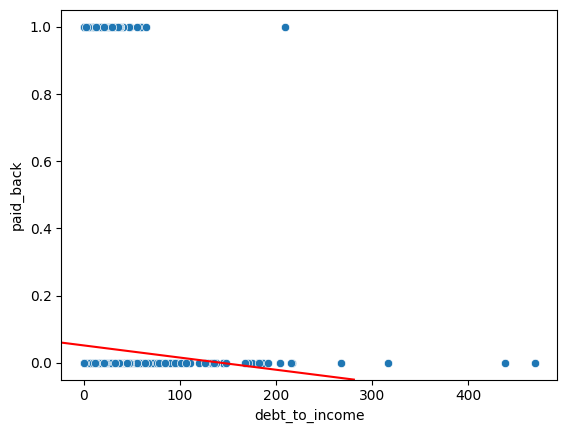

In [51]:
intercept, slope = loan_vs_debt.params
sns.scatterplot(x='debt_to_income',
                y='paid_back',
                data=loans_data_df)
plt.axline(xy1=(0, intercept), slope = slope, color = 'red')